In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_score
)

from sklearn.preprocessing import label_binarize


In [2]:
df = pd.read_csv("dataset_limpio.csv")
df.head()

,pt,eta,phi,charge,pos_x,pos_y,pos_z,particle_type,event_id
0,2.400150,0.739663,1.62212,1.0,0.000647,0.000633,0.039879,electron,22109111
1,1.314830,0.945947,-3.09573,1.0,0.000698,0.000623,-0.029173,track,22109111
2,1.384250,-1.488470,-2.93427,1.0,0.000703,0.000611,-0.029091,track,22109111
3,0.973126,0.576321,-2.91378,1.0,0.000704,0.000611,-0.020457,track,22109111
4,1.697150,1.373240,-2.92621,1.0,0.000701,0.000623,-0.020329,track,22109111


In [3]:
# Variables predictoras y objetivo
X = df[["pt", "eta", "phi", "charge", "pos_x", "pos_y", "pos_z"]]
y = df["particle_type"]

# Codificación de etiquetas
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
classes = encoder.classes_

# División entrenamiento-prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Escalado obligatorio para KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
%%time
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2]  # Para la distancia Minkowski
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
)

grid.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)

# Modelo final entrenado una sola vez
model_knn = grid.best_estimator_


Mejores hiperparámetros encontrados:
{'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
CPU times: user 927 ms, sys: 246 ms, total: 1.17 s
Wall time: 2min 53s


=== Reporte de clasificación - KNN ===
              precision    recall  f1-score   support

    electron       0.20      0.03      0.05        37
        muon       0.00      0.00      0.00        99
      photon       0.94      0.92      0.93        63
       track       0.98      1.00      0.99      7528

    accuracy                           0.98      7727
   macro avg       0.53      0.49      0.49      7727
weighted avg       0.97      0.98      0.97      7727



/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


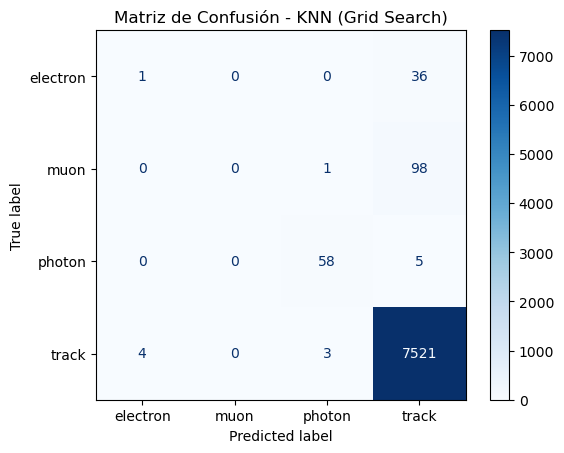

In [5]:
y_pred_knn = model_knn.predict(X_test_scaled)

print("=== Reporte de clasificación - KNN ===")
print(classification_report(y_test, y_pred_knn, target_names=classes))

cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - KNN (Grid Search)")
plt.show()


/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


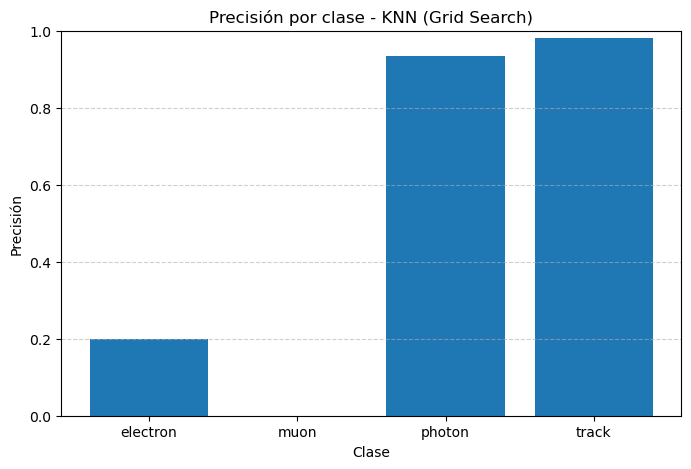

In [6]:
precisiones_knn = precision_score(y_test, y_pred_knn, average=None)

plt.figure(figsize=(8,5))
plt.bar(classes, precisiones_knn)
plt.ylabel("Precisión")
plt.xlabel("Clase")
plt.title("Precisión por clase - KNN (Grid Search)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


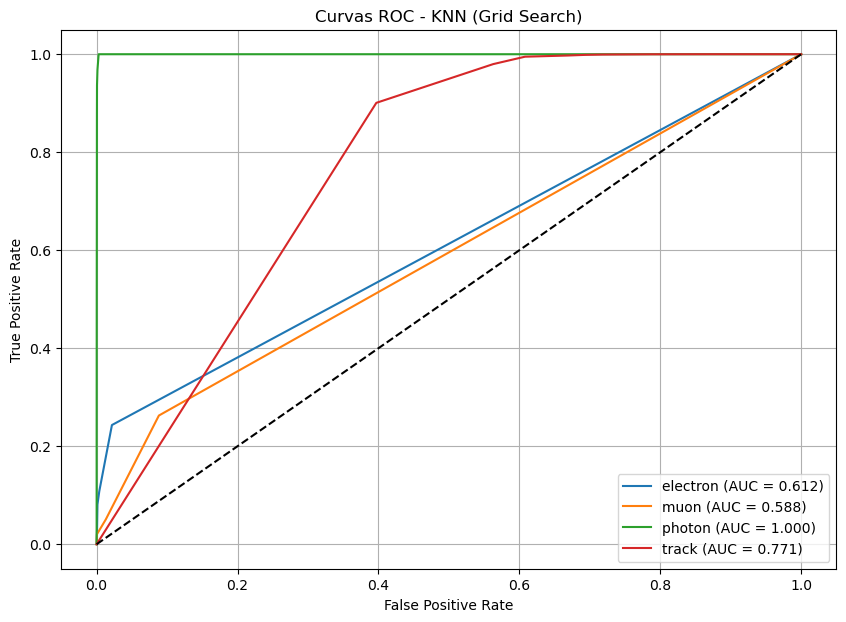

In [7]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

y_scores_knn = model_knn.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 7))

for i, clase in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores_knn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - KNN (Grid Search)")
plt.legend()
plt.grid(True)
plt.show()


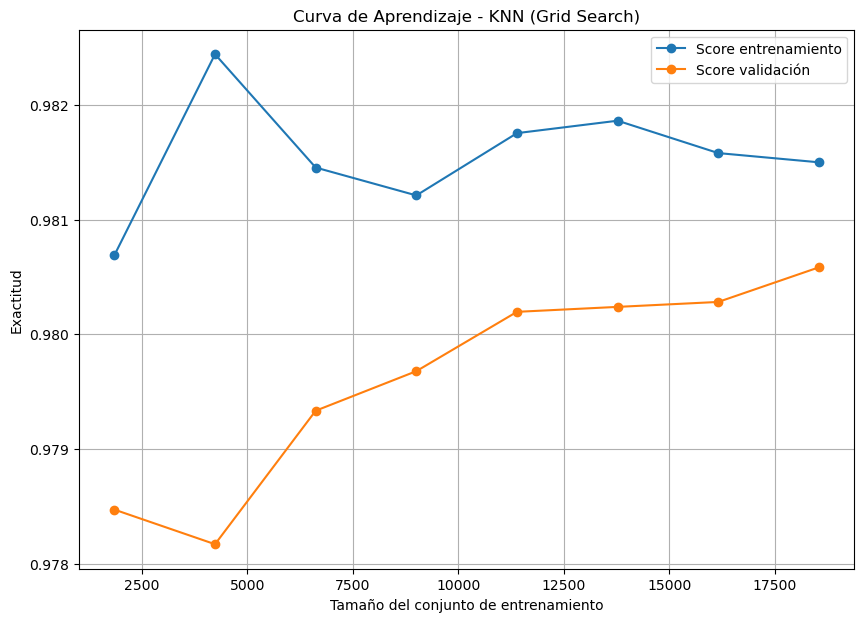

In [8]:
train_sizes, train_scores, test_scores = learning_curve(
    KNeighborsClassifier(**grid.best_params_),
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, marker="o", label="Score entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Score validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de Aprendizaje - KNN (Grid Search)")
plt.legend()
plt.grid(True)
plt.show()


## SIN TRACKS

In [9]:
df = pd.read_csv("dataset_limpio_notracks.csv")
df.head()

,pt,eta,phi,charge,pos_x,pos_y,pos_z,particle_type,event_id
0,2.400150,0.739663,1.622120,1.0,0.000647,0.000633,0.039879,electron,22109111
1,0.838852,-1.914380,2.947160,-1.0,0.000671,0.000501,-0.012415,muon,22109111
2,2.646500,-2.273300,0.817141,1.0,0.000773,0.000570,0.002240,muon,22109111
3,1.736600,-2.463090,-1.792570,1.0,0.002726,0.000183,-0.001184,muon,22109111
4,35.556000,0.005784,1.834000,0.0,0.000726,0.000609,-0.047592,photon,652620608


In [10]:
# Variables predictoras y objetivo
X = df[["pt", "eta", "phi", "charge", "pos_x", "pos_y", "pos_z"]]
y = df["particle_type"]

# Codificación de etiquetas
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
classes = encoder.classes_

# División entrenamiento-prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Escalado obligatorio para KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
%%time
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2]  # Para la distancia Minkowski
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
)

grid.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)

# Modelo final entrenado una sola vez
model_knn = grid.best_estimator_


Mejores hiperparámetros encontrados:
{'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
CPU times: user 399 ms, sys: 32.6 ms, total: 432 ms
Wall time: 1.3 s


=== Reporte de clasificación - KNN ===
              precision    recall  f1-score   support

    electron       0.63      0.32      0.43        37
        muon       0.79      0.92      0.85        99
      photon       0.97      1.00      0.98        63

    accuracy                           0.83       199
   macro avg       0.80      0.75      0.75       199
weighted avg       0.82      0.83      0.81       199



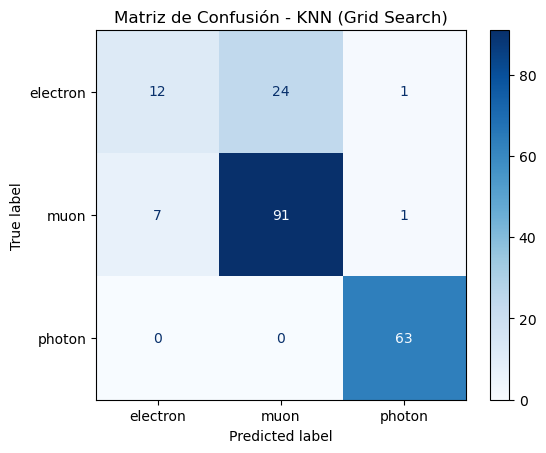

In [12]:
y_pred_knn = model_knn.predict(X_test_scaled)

print("=== Reporte de clasificación - KNN ===")
print(classification_report(y_test, y_pred_knn, target_names=classes))

cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - KNN (Grid Search)")
plt.show()


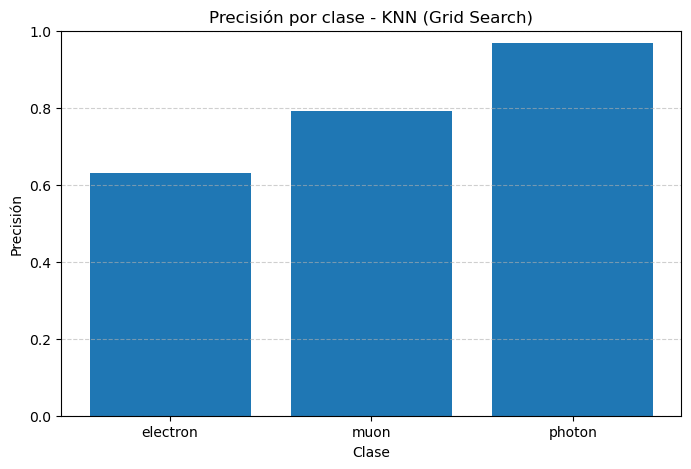

In [13]:
precisiones_knn = precision_score(y_test, y_pred_knn, average=None)

plt.figure(figsize=(8,5))
plt.bar(classes, precisiones_knn)
plt.ylabel("Precisión")
plt.xlabel("Clase")
plt.title("Precisión por clase - KNN (Grid Search)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


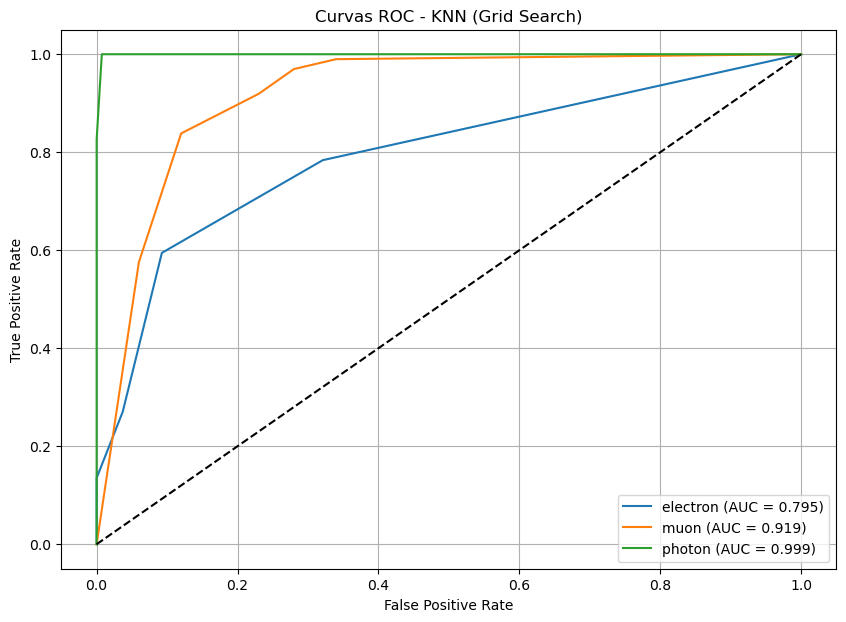

In [14]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

y_scores_knn = model_knn.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 7))

for i, clase in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores_knn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - KNN (Grid Search)")
plt.legend()
plt.grid(True)
plt.show()


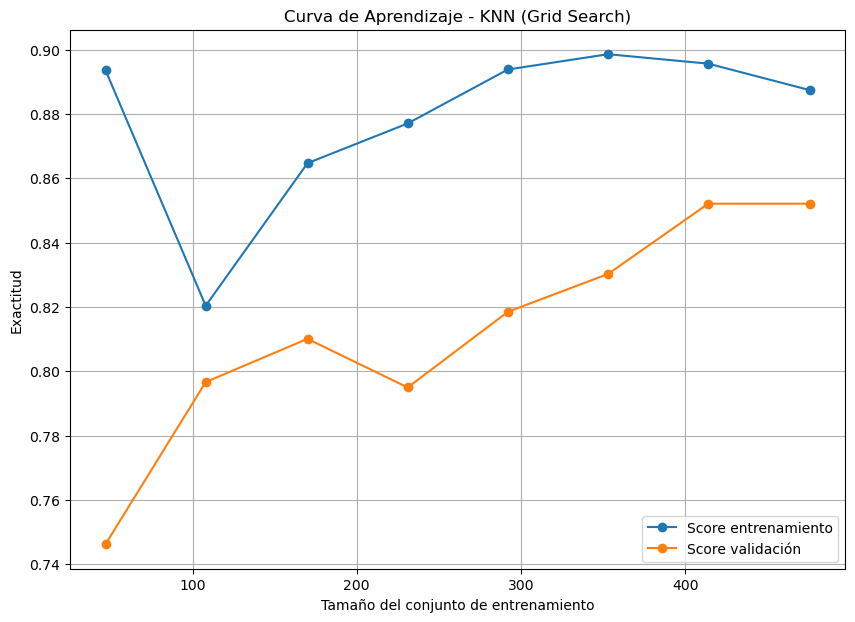

In [15]:
train_sizes, train_scores, test_scores = learning_curve(
    KNeighborsClassifier(**grid.best_params_),
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, marker="o", label="Score entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Score validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de Aprendizaje - KNN (Grid Search)")
plt.legend()
plt.grid(True)
plt.show()
